<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>

# Laboratorium nr 10: Szeregi czasowe. Architektura Transformer.
W poprzednim notatniku wykorzystywaliśmy sieci rekurencyjne (LSTM) wzbogacone o prostą warstwę atencji (Bahdanau Attention), aby skupić uwagę modelu na najistotniejszych elementach sekwencji wejściowej. 

Teraz zrobimy krok naprzód i zaimplementujemy model **Transformer**, który całkowicie rezygnuje z warstw rekurencyjnych na rzecz mechanizmu **Multi-Head Self-Attention**. Transformery przetwarzają całą sekwencję jednocześnie, co znacząco przyspiesza trening, ale wymaga dodatkowego uwzględnienia informacji o kolejności danych (tzw. *Positional Encoding*).

## Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import datetime
import matplotlib.pyplot as plt

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Pandas version:", pd.__version__)

2026-04-14 22:19:10.798822: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Numpy version: 2.4.2
Tensorflow version: 2.20.0
Keras version: 3.13.2
Pandas version: 2.3.3


## Wczytanie danych
Dane o transakcjach umieszczone są w pliku `data_trade_PLKGHM000017.tar.gz'` (do poprania na platformie Delta). Dane są w formacie DataFrame z biblioteki pandas w pliku pickle dodatkowo skompresowane (`gzip`). W pliku znajdują się wszystkie transakcje spółki KGHM z lat 2014-2021.

In [2]:
df = pd.read_pickle("data_trade_PLKGHM000017.tar.gz")
df["datetime"] = (pd.to_datetime(df["datetime"], unit="ns", utc=True)).dt.tz_convert(
    "Europe/Warsaw"
)
print("Liczba rekordów:", len(df))
df.head()

Liczba rekordów: 10262543


,datetime,trade_id,price,volume,nb_instruments,dividend,split,opening_trade_indicator,trade_origin
0,2014-01-02 09:00:00.006132+01:00,1,118.8,1,200000000,,,O,B
1,2014-01-02 09:00:00.006141+01:00,2,118.8,10,200000000,,,O,B
2,2014-01-02 09:00:00.006146+01:00,3,118.8,10,200000000,,,O,B
3,2014-01-02 09:00:00.006150+01:00,4,118.8,10,200000000,,,O,B
4,2014-01-02 09:00:00.006154+01:00,5,118.8,10,200000000,,,O,B


## Przygotowanie danych

In [3]:
sample_x = []
sample_y = []
df_grouped = df.groupby([df["datetime"].dt.date])
for d, g in df_grouped:
    df_day = (
        g.set_index("datetime")
        .resample("1min")
        .agg({"price": "last", "volume": "sum", "trade_id": "count"})
    )
    df_day["price"] = df_day["price"].ffill()
    df_day["volume"] = df_day["volume"].fillna(0)
    df_day["trade_id"] = df_day["trade_id"].fillna(0)
    sample_x.append(df_day.values[:95].copy())
    sample_y.append(df_day.values[-1, 0].copy())

In [4]:
nsample_x = np.zeros((len(sample_x) - 5, 95, 3))
nsample_y = np.zeros((len(sample_x) - 5))
my = np.zeros((len(sample_x) - 5))
sy = np.zeros((len(sample_x) - 5))
for i in range(5, len(sample_x)):
    dx = sample_x[i - 5 : i]
    dy = sample_y[i - 5 : i]
    mx = np.mean(dx, axis=(0, 1))
    sx = np.std(dx, axis=(0, 1))
    nsample_x[i - 5] = (sample_x[i] - mx) / sx
    mx = np.mean(dy)
    sx = np.std(dy)
    my[i - 5] = mx
    sy[i - 5] = sx
    nsample_y[i - 5] = (sample_y[i] - mx) / sx

nsample_x.shape, nsample_y.shape

((1994, 95, 3), (1994,))

In [5]:
train_x = nsample_x[: int(0.7 * len(nsample_x))]
train_y = nsample_y[: int(0.7 * len(nsample_x))]
val_x = nsample_x[int(0.7 * len(nsample_x)) : int(0.85 * len(nsample_x))]
val_y = nsample_y[int(0.7 * len(nsample_x)) : int(0.85 * len(nsample_x))]
test_x = nsample_x[int(0.85 * len(nsample_x)) :]
test_y = nsample_y[int(0.85 * len(nsample_x)) :]
train_x.shape, train_y.shape, val_x.shape, val_y.shape, test_x.shape, test_y.shape

((1395, 95, 3), (1395,), (299, 95, 3), (299,), (300, 95, 3), (300,))

## Implementacja bloku Transformera

W przeciwieństwie do bibliotek NLP (gdzie mamy gotowe implementacje), dla szeregów czasowych często budujemy własny blok Enkodera, używając warstwy `MultiHeadAttention`. 
Standardowy blok składa się z:
1. Warstwy `LayerNormalization`
2. Mechanizmu `MultiHeadAttention`
3. Połączenia rezydualnego (Skip connection)
4. Sieci Feed-Forward (złożonej z warstw Dense lub Conv1D z rozmiarem jądra 1)

In [6]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Część 1: Mechanizm Attention i Normalizacja
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Część 2: Sieć Feed-Forward (FFN) i Normalizacja
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

## Model Keras
Model szeregów czasowych oparty na Transformerze wymaga odpowiedniego wstrzyknięcia informacji o czasie (Positional Encoding). Dla uproszczenia, w wielu problemach numerycznych szeregów czasowych, można posłużyć się warstwami Conv1D na początku modelu (jak robiliśmy to poprzednio), które uczą się lokalnych zależności czasowych, zanim przekażą dane do Transformera.

In [7]:
def build_transformer_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=input_shape)
    # x = inputs
    x = layers.Conv1D(64, 12, strides=3, activation="relu")(inputs)
    # x = layers.Conv1D(128, 10, strides=2, activation='relu')(x)
    # x = layers.Conv1D(128, 5, strides=2, activation='relu')(x)

    # Budowa N bloków Transformera
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # Redukcja wymiarowości (Global Average Pooling działa tu często lepiej niż Flatten)
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    # Warstwy klasycznej sieci MLP na końcu
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(1, activation="linear")(x)  # Regresja - prognozowanie ceny
    return keras.Model(inputs, outputs)

In [8]:
INPUT_SHAPE = (95, 3)

model = build_transformer_model(
    input_shape=INPUT_SHAPE,
    head_size=64,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=2,
    mlp_units=[128],
    mlp_dropout=0.2,
    dropout=0.1,
)

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=1e-4))

model.summary()

I0000 00:00:1776197984.231773  334945 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 95, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 28, 64)    │      2,368 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 28, 64)    │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 28, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 28, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 28, 4)     │        260 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 28, 4)     │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 28, 64)    │        320 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 28, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 28, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 28, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 28, 64)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 28, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 28, 4)     │        260 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 28, 4)     │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 28, 64)    │        320 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 28, 64)    │          0 │ conv1d_4[0][0], 

 Total params: 140,617 (549.29 KB)

 Trainable params: 140,617 (549.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
callbacks = [keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]

history = model.fit(
    train_x,
    train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/100


2026-04-14 22:19:54.917963: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f7790003510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-14 22:19:54.918006: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-04-14 22:19:55.176136: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 22:19:56.991268: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 3/22 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.2381

I0000 00:00:1776198008.554801  335148 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 832ms/step - loss: 4.9135 - val_loss: 4.4044
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.3556 - val_loss: 3.9475
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.0169 - val_loss: 3.4269
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.4775 - val_loss: 2.4296
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.0027 - val_loss: 2.1381
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.8331 - val_loss: 2.1548
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.7704 - val_loss: 2.0813
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.7313 - val_loss: 2.0272
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.6724 - val_loss: 2.0939
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.6720 - val_loss: 2.0120
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.6910 - val_loss: 2.0094
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2

In [10]:
model.evaluate(test_x, test_y)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 1.9643


1.964257836341858

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


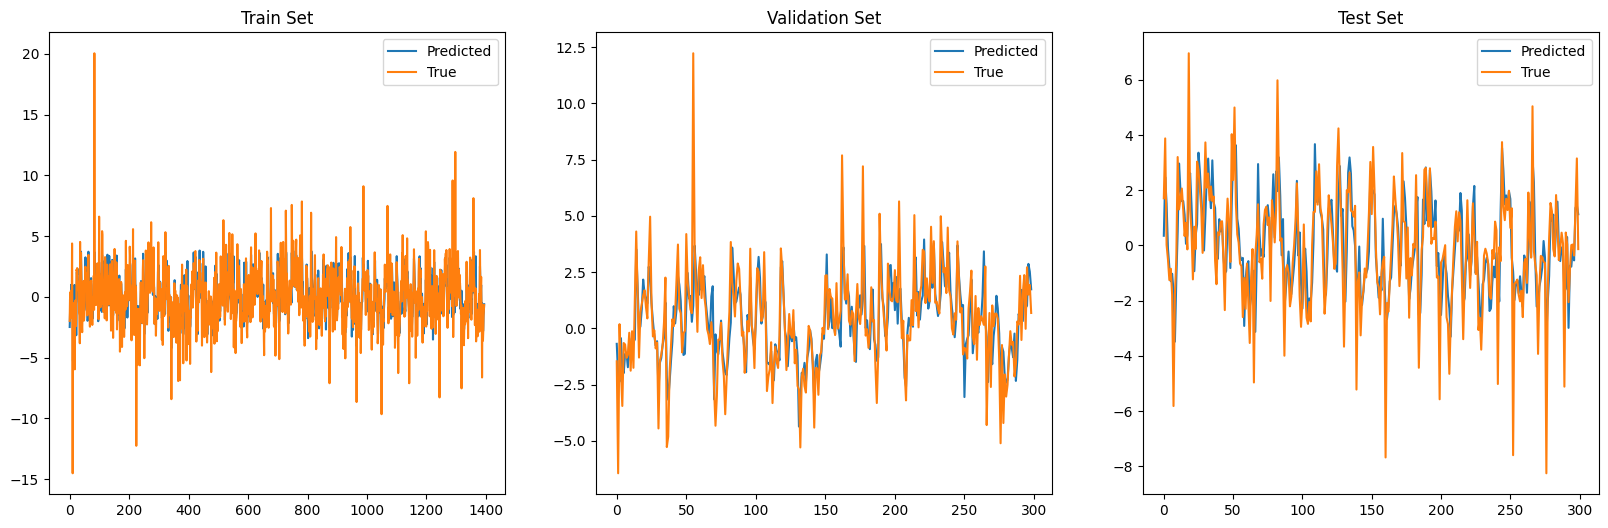

In [11]:
pred1 = model.predict(train_x)
pred2 = model.predict(val_x)
pred3 = model.predict(test_x)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(pred1.flatten(), label="Predicted")
plt.plot(train_y, label="True")
plt.title("Train Set")
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(pred2.flatten(), label="Predicted")
plt.plot(val_y, label="True")
plt.title("Validation Set")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(pred3.flatten(), label="Predicted")
plt.plot(test_y, label="True")
plt.title("Test Set")
plt.legend()
plt.show()

## Ćwiczenia
1. Porównanie z modelem RNN/LSTM: Wytrenuj model Transformer na tych samych oknach czasowych co model z Laboratorium nr 9. Porównaj metryki błędów (MSE, MAE) na zbiorze testowym oraz całkowity czas treningu obu architektur.

2. Strojenie hiperparametrów (Hyperparameter Tuning): Architektura Transformera jest bardzo czuła na hiperparametry. Sprawdź, jak na wynik wpłynie:

    - Zmiana liczby głowic atencji (num_heads = 2, 4, 8).

    - Zwiększenie/zmniejszenie głębokości modelu (num_transformer_blocks).

3. Analiza atencji: Wyprowadź wagi z warstwy MultiHeadAttention (wymaga to modyfikacji wywołania warstwy w Kerasie, aby zwracała `attention_scores`) i spróbuj zwizualizować mapę ciepła (heatmap) pokazującą, na które historyczne transakcje model zwraca największą uwagę podczas predykcji.

4. Positional Encoding: Model z zaimplementowanej dzisiaj postaci nie ma jawnego kodowania pozycji (tzw. vanilla transformer słabo radzi sobie z kolejnością w gołych szeregach numerycznych). Zaimplementuj matematyczny Positional Encoding (funkcje sinus/kosinus) lub dodaj warstwę wektorów zanurzeń (Embedding), aby sprawdzić, czy poprawi to możliwości prognostyczne modelu.

In [12]:
import time

tf.random.set_seed(42)
np.random.seed(42)


def build_lstm_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="linear")(x)
    return keras.Model(inputs, outputs)


def compile_model(m):
    m.compile(
        loss="mse",
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        metrics=[
            keras.metrics.MeanSquaredError(name="mse"),
            keras.metrics.MeanAbsoluteError(name="mae"),
        ],
    )
    return m


# Transformer
transformer_model = build_transformer_model(
    input_shape=INPUT_SHAPE,
    head_size=64,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=2,
    mlp_units=[128],
    mlp_dropout=0.2,
    dropout=0.1,
)
compile_model(transformer_model)

start = time.perf_counter()
history_transformer = transformer_model.fit(
    train_x,
    train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=0,
)
transformer_time = time.perf_counter() - start
transformer_results = transformer_model.evaluate(test_x, test_y, verbose=0)

# LSTM
lstm_model = build_lstm_model(INPUT_SHAPE)
compile_model(lstm_model)

start = time.perf_counter()
history_lstm = lstm_model.fit(
    train_x,
    train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=0,
)
lstm_time = time.perf_counter() - start
lstm_results = lstm_model.evaluate(test_x, test_y, verbose=0)

comparison = pd.DataFrame(
    {
        "Model": ["Transformer", "LSTM"],
        "Test MSE": [transformer_results[1], lstm_results[1]],
        "Test MAE": [transformer_results[2], lstm_results[2]],
        "Training time [s]": [transformer_time, lstm_time],
    }
)

comparison

,Model,Test MSE,Test MAE,Training time [s]
0,Transformer,1.980065,1.038769,55.892770
1,LSTM,1.834587,0.990503,56.257292


In [13]:
from itertools import product

heads_grid = [2, 4, 8]
blocks_grid = [1, 2, 3]

tuning_results = []

for num_heads, num_blocks in product(heads_grid, blocks_grid):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model_hp = build_transformer_model(
        input_shape=INPUT_SHAPE,
        head_size=64,
        num_heads=num_heads,
        ff_dim=4,
        num_transformer_blocks=num_blocks,
        mlp_units=[128],
        mlp_dropout=0.2,
        dropout=0.1,
    )
    compile_model(model_hp)

    cb = [keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]

    start = time.perf_counter()
    history_hp = model_hp.fit(
        train_x,
        train_y,
        validation_data=(val_x, val_y),
        epochs=100,
        batch_size=64,
        callbacks=cb,
        verbose=0,
    )
    train_time = time.perf_counter() - start

    val_metrics = model_hp.evaluate(val_x, val_y, verbose=0)
    test_metrics = model_hp.evaluate(test_x, test_y, verbose=0)

    tuning_results.append(
        {
            "num_heads": num_heads,
            "num_transformer_blocks": num_blocks,
            "best_epoch": int(np.argmin(history_hp.history["val_mse"]) + 1),
            "val_mse": val_metrics[1],
            "val_mae": val_metrics[2],
            "test_mse": test_metrics[1],
            "test_mae": test_metrics[2],
            "train_time_s": train_time,
        }
    )

tuning_df = pd.DataFrame(tuning_results).sort_values("test_mse").reset_index(drop=True)
print("Ranking konfiguracji (wg test_mse):")
display(tuning_df)

print("\nMacierz test_mse (wiersze=liczba bloków, kolumny=liczba głowic):")
display(
    tuning_df.pivot(
        index="num_transformer_blocks", columns="num_heads", values="test_mse"
    )
)

Ranking konfiguracji (wg test_mse):


,num_heads,num_transformer_blocks,best_epoch,val_mse,val_mae,test_mse,test_mae,train_time_s
0,2,3,25,2.017834,0.953754,1.861208,0.985228,74.825480
1,2,2,24,1.923210,0.929063,1.897980,0.997844,59.510095
2,4,2,15,1.997308,0.953639,1.909959,0.996086,54.519579
3,4,1,33,1.958237,0.953043,1.918596,1.004525,44.705984
4,8,1,21,1.970868,0.935330,1.947310,1.002074,44.917234
5,8,2,10,2.082163,0.963582,1.958847,1.000724,55.812042
6,4,3,21,1.956547,0.948940,1.964141,1.015653,69.918182
7,2,1,21,1.972884,0.948013,1.990608,1.013551,60.228630
8,8,3,5,1.995712,0.969574,2.050154,1.048427,69.172340



Macierz test_mse (wiersze=liczba bloków, kolumny=liczba głowic):


num_heads,2,4,8
num_transformer_blocks,,,
1,1.990608,1.918596,1.947310
2,1.897980,1.909959,1.958847
3,1.861208,1.964141,2.050154


Kształt attention_scores: (1, 4, 28, 28)


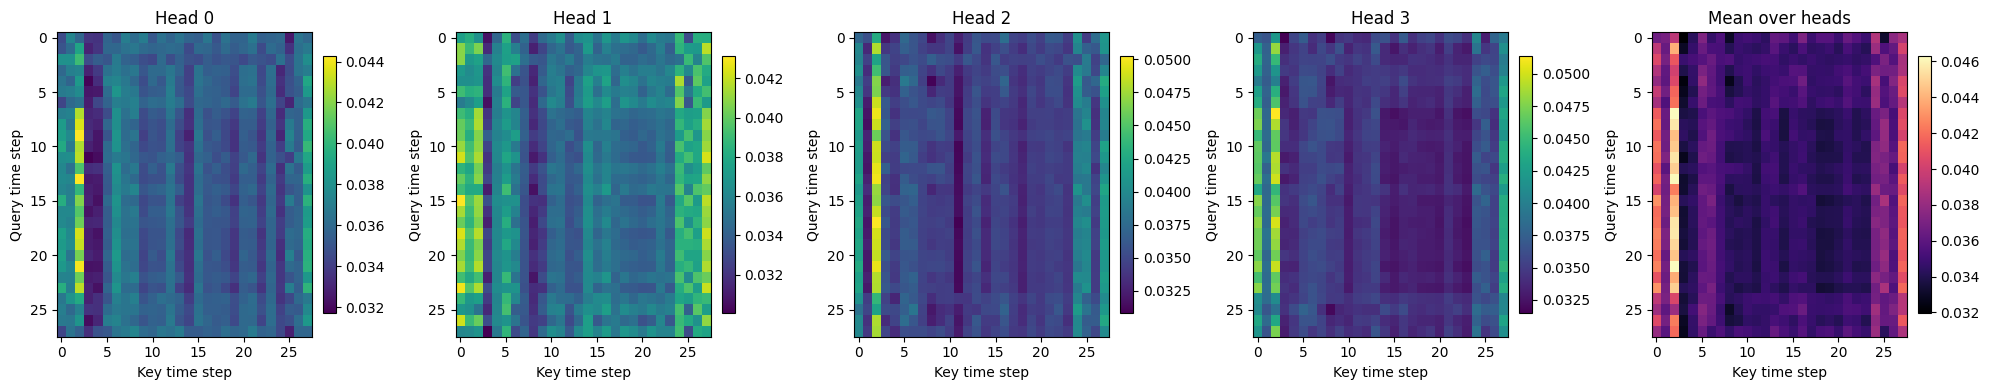

In [ ]:
mha_layers = [
    l for l in transformer_model.layers if isinstance(l, layers.MultiHeadAttention)
]
if not mha_layers:
    raise ValueError("Nie znaleziono warstwy MultiHeadAttention w transformer_model.")
mha_layer = mha_layers[0]

mha_input_model = keras.Model(
    inputs=transformer_model.input,
    outputs=mha_layer.input[0],
)

sample_idx = 0
x_sample = test_x[sample_idx : sample_idx + 1]

qv = mha_input_model.predict(x_sample, verbose=0)
_, attention_scores = mha_layer(qv, qv, return_attention_scores=True, training=False)

att = attention_scores.numpy()[0]
att_mean = att.mean(axis=0)

print("Kształt attention_scores:", attention_scores.shape)

num_heads = att.shape[0]
fig, axes = plt.subplots(1, num_heads + 1, figsize=(4 * (num_heads + 1), 4))

for h in range(num_heads):
    im = axes[h].imshow(att[h], aspect="auto", cmap="viridis")
    axes[h].set_title(f"Head {h}")
    axes[h].set_xlabel("Key time step")
    axes[h].set_ylabel("Query time step")
    plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.04)

im = axes[-1].imshow(att_mean, aspect="auto", cmap="magma")
axes[-1].set_title("Mean over heads")
axes[-1].set_xlabel("Key time step")
axes[-1].set_ylabel("Query time step")
plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [15]:
class SinusoidalPositionalEncoding(layers.Layer):
    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        d_model = tf.shape(inputs)[2]

        position = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        div_term = tf.exp(
            tf.cast(tf.range(0, d_model, 2), tf.float32)
            * (-np.log(10000.0) / tf.cast(d_model, tf.float32))
        )

        angles = position * div_term[tf.newaxis, :]
        pe = tf.concat([tf.sin(angles), tf.cos(angles)], axis=-1)

        pe = pe[tf.newaxis, :, :]
        return inputs + tf.cast(pe, inputs.dtype)


def build_transformer_model_with_pe(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 12, strides=3, activation="relu")(inputs)
    x = SinusoidalPositionalEncoding()(x)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    outputs = layers.Dense(1, activation="linear")(x)
    return keras.Model(inputs, outputs)


tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

pe_model = build_transformer_model_with_pe(
    input_shape=INPUT_SHAPE,
    head_size=64,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=2,
    mlp_units=[128],
    mlp_dropout=0.2,
    dropout=0.1,
)
compile_model(pe_model)

cb = [keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)]

start_pe = time.perf_counter()
history_pe = pe_model.fit(
    train_x,
    train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=64,
    callbacks=cb,
    verbose=0,
)
pe_time = time.perf_counter() - start_pe
pe_results = pe_model.evaluate(test_x, test_y, verbose=0)  # [loss, mse, mae]

comparison_pe = pd.DataFrame(
    {
        "Model": ["Transformer (baseline)", "Transformer + Positional Encoding"],
        "Test MSE": [transformer_results[1], pe_results[1]],
        "Test MAE": [transformer_results[2], pe_results[2]],
        "Training time [s]": [transformer_time, pe_time],
    }
)
display(comparison_pe)

,Model,Test MSE,Test MAE,Training time [s]
0,Transformer (baseline),1.980065,1.038769,55.892770
1,Transformer + Positional Encoding,1.857717,0.994492,92.999981
